# Explore Bow-Tie Overlaps

Visualize adjacent bow-ties and their pixel separations for a single bow-tie boundary.

In [1]:
import sys
import os
import numpy as np

# Add the py directory so we can import modis_matchups
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'py'))
from modis_matchups import load_latlon, reshape_to_bowties, haversine

# Reset backend to interactive after importing modis_matchups (which sets Agg)
import matplotlib
#matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

In [2]:
#%matplotlib notebook

In [3]:
# Load data
data_file = os.path.join('..', 'data', 'latlon.mat')
lat, lon = load_latlon(data_file)
lat_bt, lon_bt, n_skip = reshape_to_bowties(lat, lon)
print(f'{lat_bt.shape[0]} complete bow-ties, skipped {n_skip} lines')

4026 complete bow-ties, skipped 5 lines


In [4]:
# ---- Choose a bow-tie to explore ----
B = 900  # Change this to explore different boundaries

## Plot lat/lon of bow-ties B and B+1

Each detector within a bow-tie is plotted as a separate line. Blue = B, red = B+1.

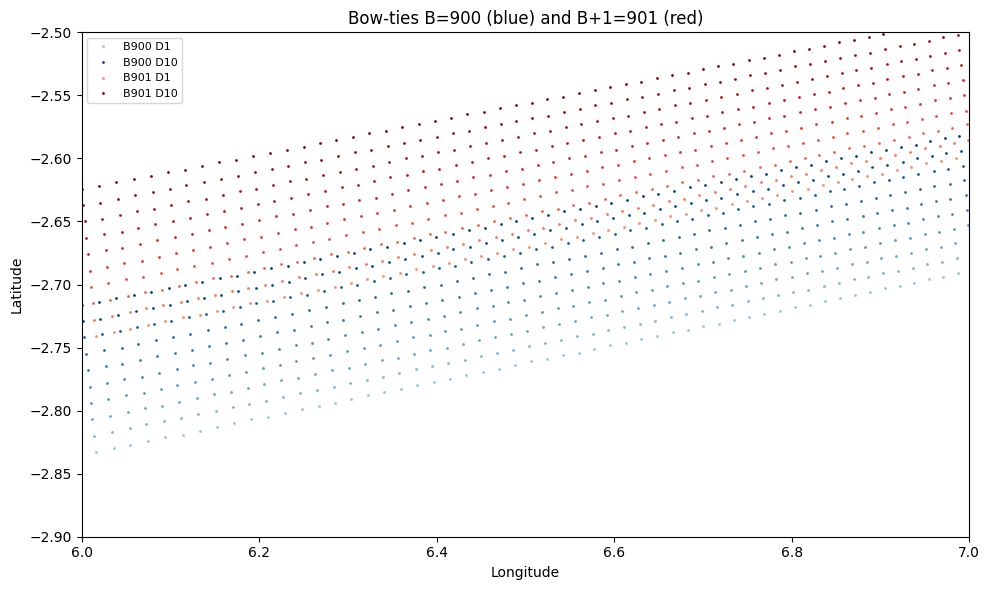

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

psz = 2.
# Bow-tie B: detectors D=1-10 in blue shades
for d in range(10):
    ax.plot(lon_bt[B, d, :], lat_bt[B, d, :],
            '.', ms=psz, color=plt.cm.Blues(0.4 + 0.06 * d),
            label=f'B{B} D{d+1}' if d in [0, 9] else None)

# Bow-tie B+1: detectors D=1-10 in red shades
for d in range(10):
    ax.plot(lon_bt[B+1, d, :], lat_bt[B+1, d, :],
            '.', ms=psz, color=plt.cm.Reds(0.4 + 0.06 * d),
            label=f'B{B+1} D{d+1}' if d in [0, 9] else None)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Bow-ties B={B} (blue) and B+1={B+1} (red)')
#
if True:
    #ax.set_xlim(12.5, 13.)
    #ax.set_ylim(-2., -1.5)
    ax.set_xlim(6., 7.)
    ax.set_ylim(-2.9, -2.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
lat_bt.shape

(4026, 10, 1354)

## Haversine distances between adjacent bow-ties

Compute pixel-center separations for all 12 candidate detector pairs (D_i in {7-10} of B vs D_j in {1-3} of B+1), restricted to the same column.

In [7]:
# Compute haversine distances for all candidate detector pairs
# D_i in {7,8,9,10} (0-idx: 6-9) of B, D_j in {1,2,3} (0-idx: 0-2) of B+1
all_dists = {}
for d_i in range(5, 10):
    for d_j in range(0, 3):
        dist = haversine(
            lat_bt[B, d_i, :], lon_bt[B, d_i, :],
            lat_bt[B+1, d_j, :], lon_bt[B+1, d_j, :])
        all_dists[(d_i+1, d_j+1)] = dist  # store with 1-indexed keys

# Combine all distances into one array for the histogram
all_vals = np.concatenate(list(all_dists.values()))
print(f'Total comparisons: {len(all_vals)} (12 pairs x 1354 columns)')
print(f'Min separation: {all_vals.min():.1f} m')
print(f'Max separation: {all_vals.max():.0f} m')
print(f'Pairs with sep < 1000 m: {(all_vals < 1000).sum()}')

Total comparisons: 20310 (12 pairs x 1354 columns)
Min separation: 666.5 m
Max separation: 8120 m
Pairs with sep < 1000 m: 1607


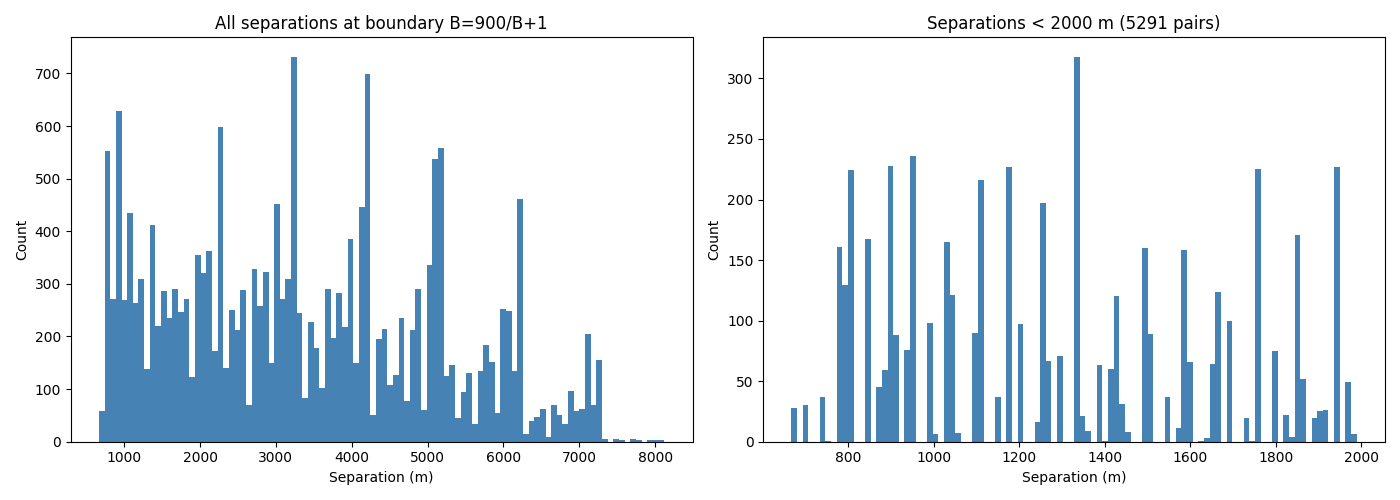

In [8]:
# Histogram of separations (zoom into < 2000 m where overlaps occur)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all separations
axes[0].hist(all_vals, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Separation (m)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'All separations at boundary B={B}/B+1')

# Right: zoom to < 2000 m
close = all_vals[all_vals < 2000]
axes[1].hist(close, bins=100, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Separation (m)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Separations < 2000 m ({len(close)} pairs)')

plt.tight_layout()
plt.show()

## Separation vs column for each detector pair

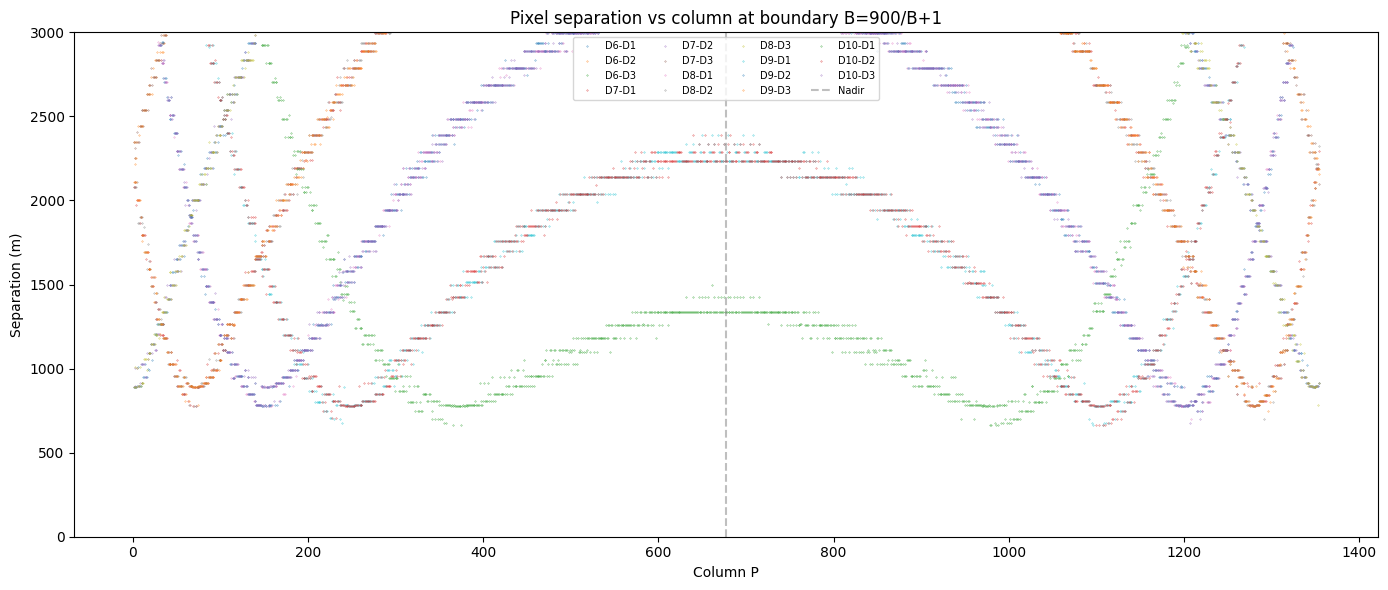

In [44]:
# Separation vs column for each detector pair
fig, ax = plt.subplots(figsize=(14, 6))
columns = np.arange(1, 1355)

for (di, dj), dist in all_dists.items():
    ax.plot(columns, dist, '.', ms=0.5, label=f'D{di}-D{dj}')

ax.axvline(x=677, color='gray', ls='--', alpha=0.5, label='Nadir')
ax.set_xlabel('Column P')
ax.set_ylabel('Separation (m)')
ax.set_ylim(0, 3000)
ax.set_title(f'Pixel separation vs column at boundary B={B}/B+1')
ax.legend(fontsize=7, ncol=4, loc='upper center')
plt.tight_layout()
plt.show()